In [1]:
import numpy as np
from sklearn.linear_model import GammaRegressor, PoissonRegressor
import jax
import optax.tree_utils as otu
import optax
from matplotlib import pyplot as plt
from scipy.stats import gamma

In [32]:
jax.config.update("jax_enable_x64", True)

In [33]:
X = np.random.normal(size=(1000, 4)).astype(np.float64)
beta = np.random.normal(size=(4, 1)).astype(np.float64)
y = np.random.gamma(size=(1000, 1), scale=np.exp(X @ beta), shape=1).astype(np.float64)

In [3]:
gamma_regressor = GammaRegressor()
gamma_regressor = gamma_regressor.fit(X, y)

/Users/jan-hendrikzab/src/priv/actuarial-python-tooling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [4]:
gamma_regressor.coef_

array([-0.06054047,  0.34054633,  0.22196163,  0.48845703])

In [5]:
beta

array([[-0.05012638],
       [ 0.60127594],
       [ 0.55330216],
       [ 1.01962578]])

# Poisson

In [6]:
X_poisson = np.random.normal(size=(1000, 4))
beta_poisson = np.random.normal(size=(4, 1))
y_poisson = np.random.poisson(size=(1000, 1), lam=np.exp(X_poisson @ beta_poisson))

In [7]:
poisson_regressor = PoissonRegressor()
poisson_regressor = poisson_regressor.fit(X_poisson, y_poisson)

/Users/jan-hendrikzab/src/priv/actuarial-python-tooling/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [8]:
poisson_regressor.coef_

array([-1.37974599, -0.38810949, -1.60955429, -1.72753751])

In [9]:
beta

array([[-0.05012638],
       [ 0.60127594],
       [ 0.55330216],
       [ 1.01962578]])

# Solving via Jax / Optax

In [108]:
def gamma_neg_log_loss(params, X, y):
    beta = params
    y_pred = jax.numpy.exp(X @ beta)
    return -1 * jax.numpy.mean(
        (y_pred - 1) * jax.numpy.log(y)
        - y_pred
        - y_pred * jax.numpy.log(y / (y_pred))
        # - jax.scipy.special.gamma(y_pred)
    )

In [112]:
def gamma_neg_log_loss_scipy(params, X, y) -> jax.Array:
    beta = params
    y_pred = jax.numpy.exp(X @ beta)
    res = jax.numpy.log(y_pred / y) + (y / y_pred) - 1
    res = jax.numpy.mean(res)
    return res

In [ ]:
def gamma_neg_log_loss_se(params, X, y):
    beta = params
    y_pred = jax.numpy.exp(X @ beta)
    return -1 * jax.numpy.mean(
        (y_pred - 1) * jax.numpy.log(y)
        - y_pred
        - y_pred * jax.numpy.log(y / (y_pred))
        # - jax.scipy.special.gamma(y_pred)
    )

In [ ]:
def gamma_neg_log_loss_lightgbm(params, X, y):
    beta = params
    y_pred = jax.numpy.exp(X @ beta)
    return -1 * jax.numpy.mean(
        (y_pred - 1) * jax.numpy.log(y)
        - y_pred
        - y_pred * jax.numpy.log(y / (y_pred))
        # - jax.scipy.special.gamma(y_pred)
    )

In [115]:
print(gamma_neg_log_loss(beta, X, y))
print(gamma_neg_log_loss_scipy(beta, X, y))

-0.59512320472736
0.5344043644169517


In [114]:
print(gamma_neg_log_loss(init_beta, X, y))
print(gamma_neg_log_loss_scipy(init_beta, X, y))

0.33913587356832
1.3897671578187767


In [107]:
print(jax.grad(gamma_neg_log_loss)(beta, X, y))

[[ 2.25044494e+26]
 [-1.43399926e+26]
 [ 2.00786556e+26]
 [ 1.18010935e+26]]


In [49]:
print(y_j.shape)
print(y_pred.shape)

(1000, 1)
(1000, 1)


In [116]:
# @jax.jit
def run_lbfgs(X, y, init_beta, max_iter=10, tol=0.000001):
    # https://optax.readthedocs.io/en/stable/_collections/examples/lbfgs.html#l-bfgs-solver
    value_and_grad_fun = optax.value_and_grad_from_state(gamma_neg_log_loss_scipy)
    opt = optax.lbfgs()

    def step(carry):
        params, state = carry
        value, grad = value_and_grad_fun(params, X, y, state=state)
        updates, state = opt.update(
            grad,
            state,
            params,
            value=value,
            grad=grad,
            value_fn=gamma_neg_log_loss_scipy,
            X=X,
            y=y,
        )
        params = optax.apply_updates(params, updates)

        return params, state

    def continuing_criterion(carry):
        _, state = carry
        iter_num = otu.tree_get(state, "count")
        grad = otu.tree_get(state, "grad")
        err = otu.tree_l2_norm(grad)
        return (iter_num == 0) | ((iter_num < max_iter) & (err >= tol))

    init_carry = (init_beta, opt.init(init_beta))
    final_params, final_state = jax.lax.while_loop(continuing_criterion, step, init_carry)
    return final_params  # , final_state

In [93]:
solver = optax.lbfgs()
params = init_beta
opt_state = solver.init(params)
value_and_grad = optax.value_and_grad_from_state(gamma_neg_log_loss)
for _ in range(2):
    value, grad = value_and_grad(params, X, y, state=opt_state)
    updates, opt_state = solver.update(
        grad,
        opt_state,
        params,
        value=value,
        grad=grad,
        value_fn=gamma_neg_log_loss,
        X=X,
        y=y,
    )
    print(updates)
    params = optax.apply_updates(params, updates)
    print("Objective function: {:.2E}".format(gamma_neg_log_loss(params=params, X=X, y=y, y_pred=y_pred)))

[[-15.21876876]
 [-28.70921491]
 [  4.42963443]
 [-98.20472065]]


TypeError: gamma_neg_log_loss() got an unexpected keyword argument 'params'

In [79]:
key = jax.random.key(10)
init_beta = (
    jax.random.normal(
        key,
        (X.shape[1], 1),
    )
    / 5
)
init_beta

Array([[-0.05431346],
       [-0.11269605],
       [ 0.00845763],
       [-0.30999465]], dtype=float64)

In [117]:
key = jax.random.key(10)
init_beta = (
    jax.random.normal(
        key,
        (X.shape[1], 1),
    )
    / 5
)
X_j, y_j, init_beta_j = jax.device_put((X, y, init_beta))
beta_predicted = run_lbfgs(X_j, y_j, init_beta_j)

In [120]:
print(gamma_neg_log_loss(beta_predicted, X, y))
print(gamma_neg_log_loss_scipy(beta_predicted, X, y))

-0.6426246421508452
0.5297603023959689


In [103]:
print(jax.grad(gamma_neg_log_loss)(beta_predicted, X, y))

[[8.26518788e+154]
 [3.24867084e+154]
 [3.90062086e+154]
 [2.01063028e+155]]


In [125]:
beta_predicted

Array([[ 0.62172526],
       [-0.5617127 ],
       [ 0.563805  ],
       [ 0.29903811]], dtype=float64)

In [123]:
init_beta

Array([[-0.05431346],
       [-0.11269605],
       [ 0.00845763],
       [-0.30999465]], dtype=float64)

In [124]:
beta

array([[ 0.57770019],
       [-0.5209286 ],
       [ 0.5837157 ],
       [ 0.37243524]])

# How does Gamma look like?

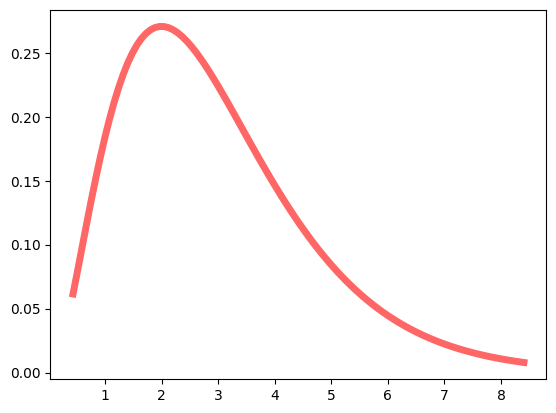

In [ ]:
fig, ax = plt.subplots(1, 1)

a = 3
mean, var, skew, kurt = gamma.stats(a, moments="mvsk")

x = np.linspace(gamma.ppf(0.01, a), gamma.ppf(0.99, a), 100)
ax.plot(x, gamma.pdf(x, a), "r-", lw=5, alpha=0.6, label="gamma pdf")